# Triangle GA - Experiment Tracker
Run the genetic algorithm and compare RMSE, MSE, CIELAB / Delta E, and embedding cosine similarity trials.

## Setup
Load the shared imports, target image, and common state used by the search and long-run sections.

In [1]:
from pathlib import Path
from io import BytesIO
import base64
import sys
import warnings

warnings.filterwarnings(
    "ignore",
)

import numpy as np
from PIL import Image
from IPython.display import HTML, display

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.config import CANVAS_H, CANVAS_W, DATA_PATH, RESULTS_DIR
from src.models import (
    TriangleCIELABSolution,
    TriangleEmbeddingSolution,
    TriangleMSESolution,
    TriangleSolution,
 )
from src.utils import (
    compute_embedding_cosine_distances_batch,
    compute_reconstruction_metrics,
    load_best_configs_from_history,
    random_search,
    run_and_report_experiment,
 )


In [2]:
target_img = Image.open(DATA_PATH).convert('RGB').resize((CANVAS_W, CANVAS_H))
target_array = np.array(target_img, dtype=np.uint8)
TriangleSolution.target = target_array
TriangleCIELABSolution.target = target_array
TriangleMSESolution.target = target_array
TriangleEmbeddingSolution.target = target_array

## Random Search
Run the short searches first. These cells build the shared CSV used later for configuration evaluation.

### RMSE Search
Run the short random search for the RMSE objective and append the generation histories to the shared CSV.

In [3]:
rmse_params = random_search(
    solution_class=TriangleSolution,
)

Starting search: 48 experiments | 200 generations each | 30 seeds/config | parallel (12 workers)
[ 1/48] Starting pop=100 | ranking / single_point / mixed | seeds=30
[ 2/48] Starting pop=100 | fitness_proportionate / order_based / gaussian | seeds=30
[ 3/48] Starting pop=100 | tournament / order_based / random_reset | seeds=30
[ 4/48] Starting pop=100 | fitness_proportionate / uniform / triangle_swap | seeds=30
[ 5/48] Starting pop=100 | fitness_proportionate / uniform / triangle_swap | seeds=30
[ 6/48] Starting pop=100 | tournament / order_based / triangle_swap | seeds=30
[ 7/48] Starting pop=100 | fitness_proportionate / arithmetic / gaussian | seeds=30
[ 8/48] Starting pop=100 | ranking / single_point / gaussian | seeds=30
[ 9/48] Starting pop=100 | ranking / order_based / triangle_swap | seeds=30
[10/48] Starting pop=100 | tournament / order_based / mixed | seeds=30
[11/48] Starting pop=100 | tournament / arithmetic / triangle_swap | seeds=30
[12/48] Starting pop=100 | fitness_prop

### MSE Search
Run the short random search for the MSE objective and append the generation histories to the shared CSV.

In [4]:
mse_params = random_search(
    solution_class=TriangleMSESolution,
)

Starting search: 48 experiments | 200 generations each | 30 seeds/config | parallel (12 workers)
[ 1/48] Starting pop=100 | ranking / single_point / mixed | seeds=30
[ 2/48] Starting pop=100 | fitness_proportionate / order_based / gaussian | seeds=30
[ 3/48] Starting pop=100 | tournament / order_based / random_reset | seeds=30
[ 4/48] Starting pop=100 | fitness_proportionate / uniform / triangle_swap | seeds=30
[ 5/48] Starting pop=100 | fitness_proportionate / uniform / triangle_swap | seeds=30
[ 6/48] Starting pop=100 | tournament / order_based / triangle_swap | seeds=30
[ 7/48] Starting pop=100 | fitness_proportionate / arithmetic / gaussian | seeds=30
[ 8/48] Starting pop=100 | ranking / single_point / gaussian | seeds=30
[ 9/48] Starting pop=100 | ranking / order_based / triangle_swap | seeds=30
[10/48] Starting pop=100 | tournament / order_based / mixed | seeds=30
[11/48] Starting pop=100 | tournament / arithmetic / triangle_swap | seeds=30
[12/48] Starting pop=100 | fitness_prop

### CIELAB / Delta E Search
Run the short random search for the Delta E objective and append the generation histories to the shared CSV.

In [5]:
cielab_params = random_search(
    solution_class=TriangleCIELABSolution,
)

Starting search: 48 experiments | 200 generations each | 30 seeds/config | parallel (12 workers)
[ 1/48] Starting pop=100 | ranking / single_point / mixed | seeds=30
[ 2/48] Starting pop=100 | fitness_proportionate / order_based / gaussian | seeds=30
[ 3/48] Starting pop=100 | tournament / order_based / random_reset | seeds=30
[ 4/48] Starting pop=100 | fitness_proportionate / uniform / triangle_swap | seeds=30
[ 5/48] Starting pop=100 | fitness_proportionate / uniform / triangle_swap | seeds=30
[ 6/48] Starting pop=100 | tournament / order_based / triangle_swap | seeds=30
[ 7/48] Starting pop=100 | fitness_proportionate / arithmetic / gaussian | seeds=30
[ 8/48] Starting pop=100 | ranking / single_point / gaussian | seeds=30
[ 9/48] Starting pop=100 | ranking / order_based / triangle_swap | seeds=30
[10/48] Starting pop=100 | tournament / order_based / mixed | seeds=30
[11/48] Starting pop=100 | tournament / arithmetic / triangle_swap | seeds=30
[12/48] Starting pop=100 | fitness_prop

## Get Best Config

In [3]:
cfg = load_best_configs_from_history()

history_csv = Path(cfg["search_history_csv"])
params = cfg["params_by_solution"]
best_by_solution = cfg["best_config_by_solution"]

rmse_params = params["TriangleSolution"]
mse_params = params["TriangleMSESolution"]
cielab_params = params["TriangleCIELABSolution"]

# Fixed embedding config (no random search for embedding)
embedding_run_params = {
    "pop_size": 100,
    "selection_name": "ranking",
    "crossover_name": "uniform",
    "mutation_name": "gaussian",
    "tournament_size": None,
    "swap_weight": None,
    "ga_settings": {
        "xo_prob": 0.9,
        "mut_prob": 0.05,
        "elitism": True,
        "n_elites": 1,
        "verbose": False,
        "diversify_on_plateau": True,
        "plateau_window": 40,
        "plateau_epsilon": 0.05,
        "mut_sigma_start": 2.0,
        "mut_sigma_end": 0.4,
        "hc_refine_every": 0,
    },
}

print(f"Search history CSV: {history_csv}")
for solution_name, short_name in [
    ("TriangleSolution", "RMSE"),
    ("TriangleMSESolution", "MSE"),
    ("TriangleCIELABSolution", "Delta E"),
]:
    selected = best_by_solution[solution_name]
    print(
        f"{short_name}: config {selected['config_id']} | "
        f"mean seed-best={selected['mean_seed_best_fitness']:.4f} "
        f"(std={selected['std_seed_best_fitness']:.4f}, n={selected['num_seeds']})"
    )

print("Embedding: using fixed manual config (no search).")

Search history CSV: /home/lucas/Desktop/cifo/results/random_search_history.csv
RMSE: config 20 | mean seed-best=38.2012 (std=1.6418, n=30)
MSE: config 20 | mean seed-best=1462.0282 (std=125.9825, n=30)
Delta E: config 20 | mean seed-best=16.6591 (std=1.1868, n=30)
Embedding: using fixed manual config (no search).


## Run Experiments with 6000 Generations
Define the long-run helpers here and execute the final experiments only after the configuration-evaluation section is ready.

Starting RMSE GA run with pop_size=100 for 6000 generations...
Gen    1 | best = 110.5908 | H_p = 0.871 | H_g = 0.940
Gen   10 | best = 84.1350 | H_p = 0.903 | H_g = 0.742
Gen   20 | best = 68.8434 | H_p = 0.854 | H_g = 0.722
Gen   30 | best = 61.9360 | H_p = 0.848 | H_g = 0.739
Gen   40 | best = 58.8579 | H_p = 0.805 | H_g = 0.696
Gen   50 | best = 55.3348 | H_p = 0.704 | H_g = 0.668
Gen   60 | best = 53.0860 | H_p = 0.746 | H_g = 0.699
Gen   70 | best = 51.8228 | H_p = 0.707 | H_g = 0.698
Gen   80 | best = 49.7220 | H_p = 0.707 | H_g = 0.689
Gen   90 | best = 48.6209 | H_p = 0.676 | H_g = 0.714
Gen  100 | best = 46.6493 | H_p = 0.708 | H_g = 0.678
Gen  110 | best = 46.6493 | H_p = 0.633 | H_g = 0.693
Gen  120 | best = 45.5960 | H_p = 0.685 | H_g = 0.672
Gen  130 | best = 45.2840 | H_p = 0.625 | H_g = 0.706
Gen  140 | best = 45.2840 | H_p = 0.547 | H_g = 0.717
Gen  150 | best = 44.8611 | H_p = 0.592 | H_g = 0.690
Gen  160 | best = 44.5639 | H_p = 0.775 | H_g = 0.684
Gen  170 | best = 

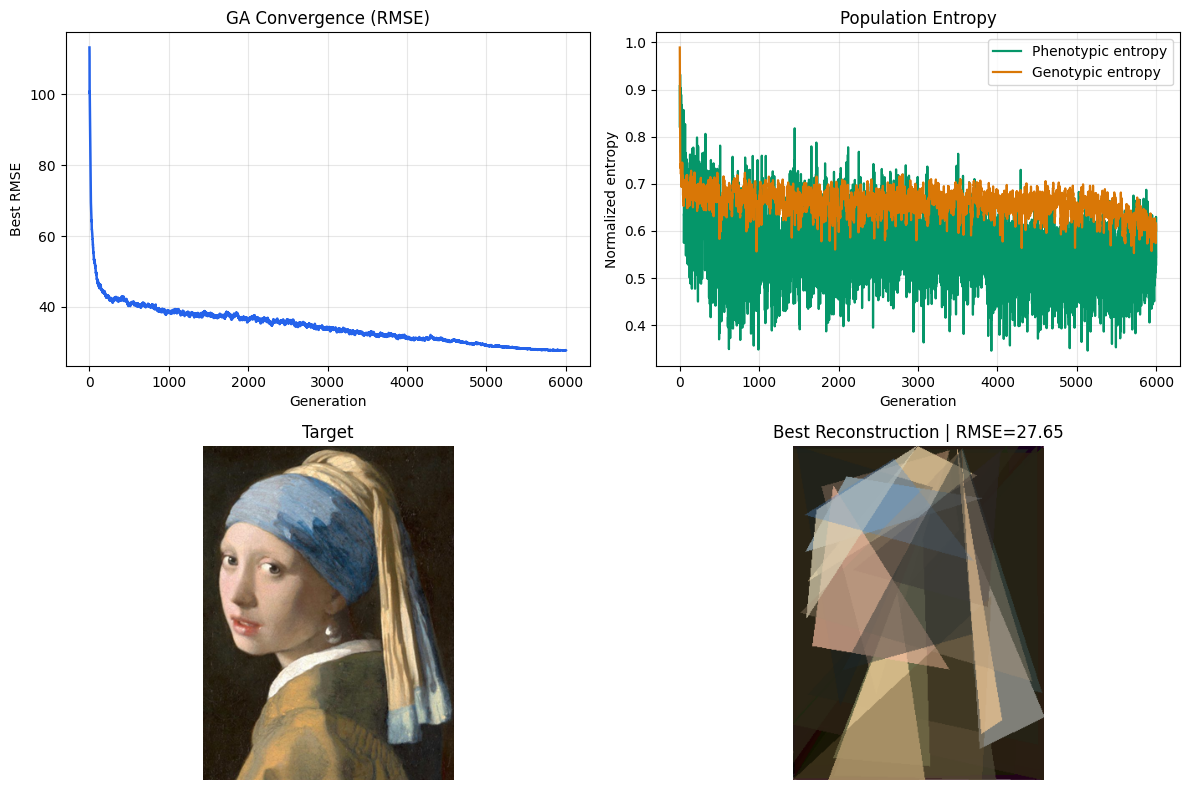

Run folder for RMSE: rmse
GIF: /home/lucas/Desktop/cifo/results/rmse/timelapse.gif


In [4]:
# One switch for all long runs
HILL_CLIMBING = False

# RMSE long run
rmse_run_name = "rmse"
rmse_best_solution, rmse_fitness_history, rmse_metrics_history, rmse_gif_path = run_and_report_experiment(
    solution_class=TriangleSolution,
    params=rmse_params,
    run_name=rmse_run_name,
    fitness_label="RMSE",
    hill_climbing=HILL_CLIMBING,
)

Starting MSE GA run with pop_size=100 for 6000 generations...
Gen    1 | best = 12230.3174 | H_p = 0.867 | H_g = 0.940
Gen   10 | best = 7078.6914 | H_p = 0.908 | H_g = 0.742
Gen   20 | best = 4739.4180 | H_p = 0.853 | H_g = 0.722
Gen   30 | best = 3836.0623 | H_p = 0.836 | H_g = 0.739
Gen   40 | best = 3464.2578 | H_p = 0.793 | H_g = 0.696
Gen   50 | best = 3061.9417 | H_p = 0.668 | H_g = 0.668
Gen   60 | best = 2818.1279 | H_p = 0.704 | H_g = 0.699
Gen   70 | best = 2685.5989 | H_p = 0.689 | H_g = 0.698
Gen   80 | best = 2472.2810 | H_p = 0.675 | H_g = 0.689
Gen   90 | best = 2363.9941 | H_p = 0.627 | H_g = 0.714
Gen  100 | best = 2176.1528 | H_p = 0.708 | H_g = 0.678
Gen  110 | best = 2176.1528 | H_p = 0.618 | H_g = 0.693
Gen  120 | best = 2078.9956 | H_p = 0.682 | H_g = 0.672
Gen  130 | best = 2050.6418 | H_p = 0.572 | H_g = 0.706
Gen  140 | best = 2050.6418 | H_p = 0.510 | H_g = 0.717
Gen  150 | best = 2012.5161 | H_p = 0.546 | H_g = 0.690
Gen  160 | best = 1985.9446 | H_p = 0.752

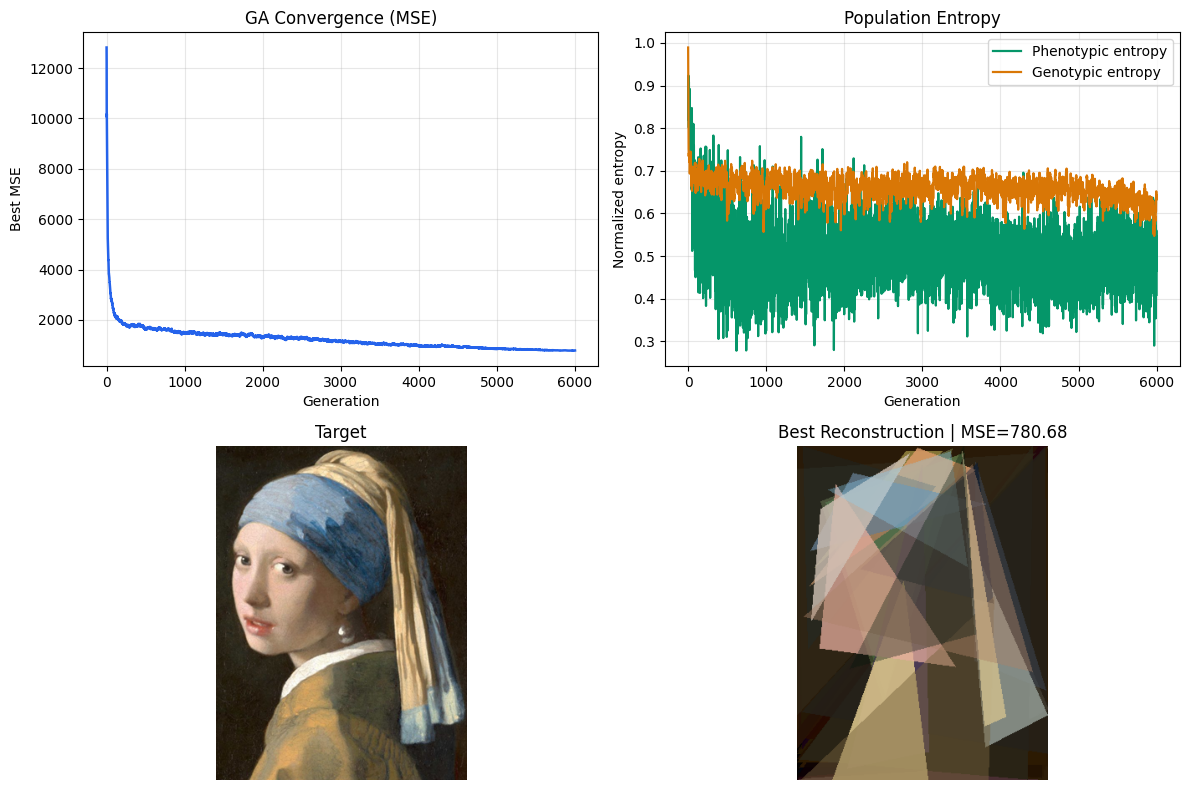

Run folder for MSE: mse
GIF: /home/lucas/Desktop/cifo/results/mse/timelapse.gif


In [5]:
# MSE long run
mse_run_name = "mse"
mse_best_solution, mse_fitness_history, mse_metrics_history, mse_gif_path = run_and_report_experiment(
    solution_class=TriangleMSESolution,
    params=mse_params,
    run_name=mse_run_name,
    fitness_label="MSE",
    hill_climbing=HILL_CLIMBING,
)

Starting Delta E GA run with pop_size=100 for 6000 generations...
Gen    1 | best = 49.2730 | H_p = 0.807 | H_g = 0.941
Gen   10 | best = 39.3138 | H_p = 0.866 | H_g = 0.726
Gen   20 | best = 30.3448 | H_p = 0.829 | H_g = 0.609
Gen   30 | best = 26.4539 | H_p = 0.872 | H_g = 0.702
Gen   40 | best = 24.2874 | H_p = 0.812 | H_g = 0.725
Gen   50 | best = 22.9949 | H_p = 0.745 | H_g = 0.733
Gen   60 | best = 22.2486 | H_p = 0.813 | H_g = 0.675
Gen   70 | best = 20.4461 | H_p = 0.731 | H_g = 0.703
Gen   80 | best = 19.9952 | H_p = 0.821 | H_g = 0.692
Gen   90 | best = 19.4359 | H_p = 0.792 | H_g = 0.679
Gen  100 | best = 19.0881 | H_p = 0.711 | H_g = 0.726
Gen  110 | best = 18.8773 | H_p = 0.639 | H_g = 0.705
Gen  120 | best = 18.8773 | H_p = 0.826 | H_g = 0.704
Gen  130 | best = 18.8773 | H_p = 0.859 | H_g = 0.713
Gen  140 | best = 18.8773 | H_p = 0.874 | H_g = 0.676
Gen  150 | best = 18.8773 | H_p = 0.713 | H_g = 0.686
Gen  160 | best = 18.8773 | H_p = 0.746 | H_g = 0.742
Gen  170 | best 

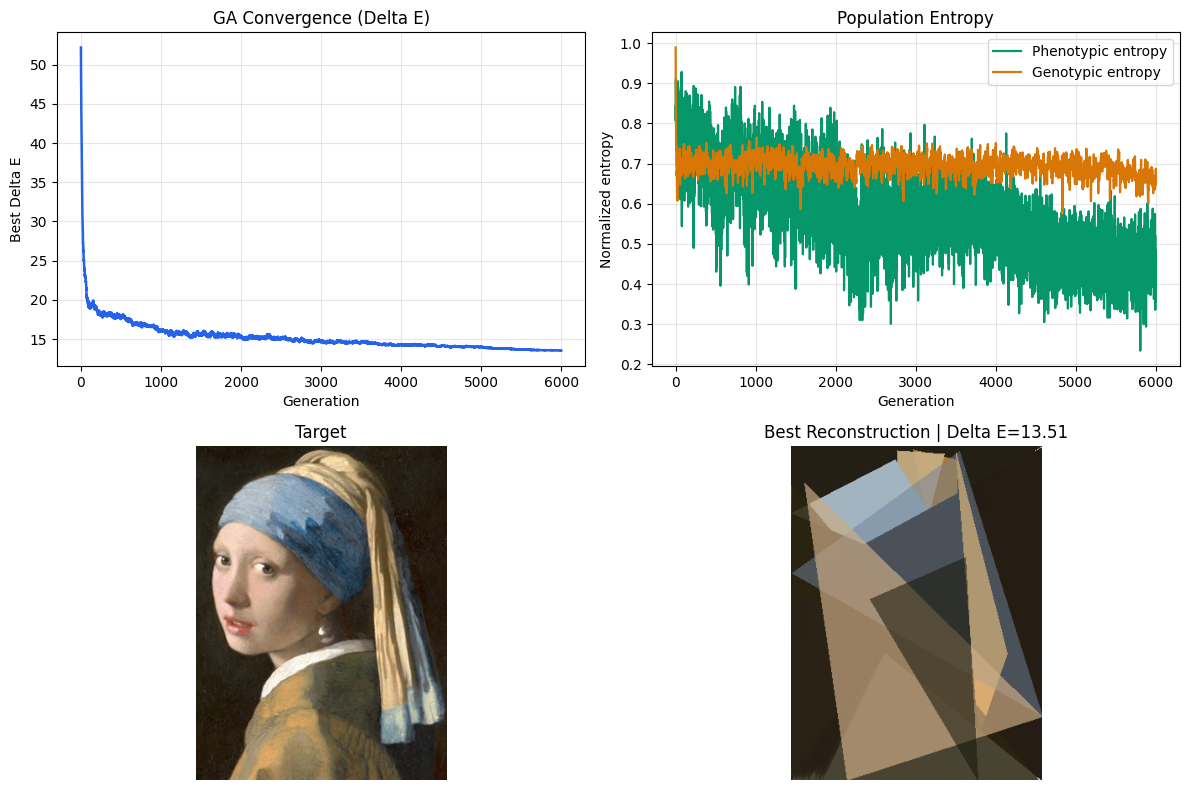

Run folder for Delta E: cielab_delta_e
GIF: /home/lucas/Desktop/cifo/results/cielab_delta_e/timelapse.gif


In [6]:
# Delta E long run
delta_e_run_name = "cielab_delta_e"
delta_e_best_solution, delta_e_fitness_history, delta_e_metrics_history, delta_e_gif_path = run_and_report_experiment(
    solution_class=TriangleCIELABSolution,
    params=cielab_params,
    run_name=delta_e_run_name,
    fitness_label="Delta E",
    hill_climbing=HILL_CLIMBING,
)

facebook/dinov2-base on cuda
Starting Embedding cosine distance GA run with pop_size=100 for 6000 generations...


Loading weights: 100%|██████████| 223/223 [00:00<00:00, 10890.62it/s]


Gen    1 | best = 0.8846 | H_p = 0.895 | H_g = 0.964
Gen   10 | best = 0.7976 | H_p = 0.883 | H_g = 0.814
Gen   20 | best = 0.7124 | H_p = 0.876 | H_g = 0.775
Gen   30 | best = 0.6568 | H_p = 0.835 | H_g = 0.782
Gen   40 | best = 0.6000 | H_p = 0.899 | H_g = 0.720
Gen   50 | best = 0.6000 | H_p = 0.866 | H_g = 0.757
  [Diversity] Plateau detected at gen 52, injecting random individuals...
Gen   60 | best = 0.5851 | H_p = 0.848 | H_g = 0.763
Gen   70 | best = 0.5851 | H_p = 0.895 | H_g = 0.683
  [Diversity] Plateau detected at gen 72, injecting random individuals...
Gen   80 | best = 0.5815 | H_p = 0.905 | H_g = 0.732
Gen   90 | best = 0.5767 | H_p = 0.826 | H_g = 0.732
  [Diversity] Plateau detected at gen 92, injecting random individuals...
Gen  100 | best = 0.5612 | H_p = 0.835 | H_g = 0.748
Gen  110 | best = 0.5534 | H_p = 0.762 | H_g = 0.675
  [Diversity] Plateau detected at gen 112, injecting random individuals...
Gen  120 | best = 0.5534 | H_p = 0.779 | H_g = 0.711
Gen  130 | bes

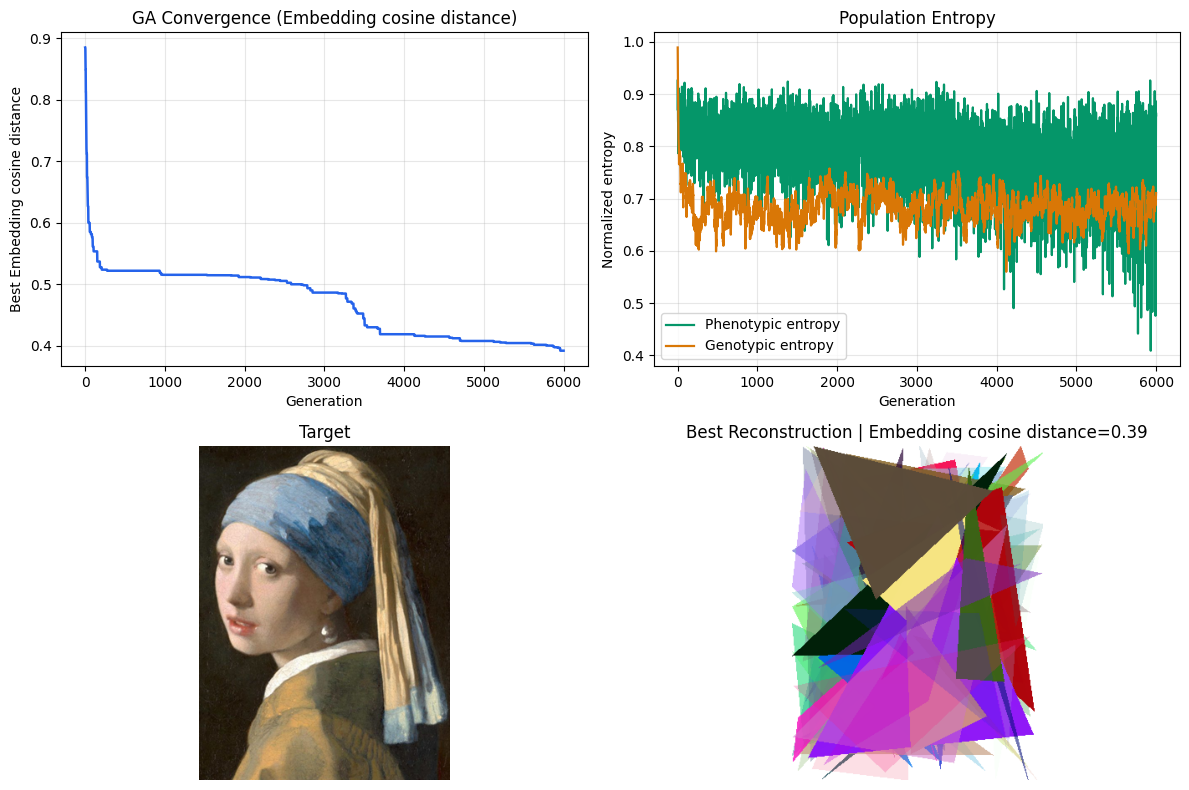

Run folder for Embedding cosine distance: embedding_cosine
GIF: /home/lucas/Desktop/cifo/results/embedding_cosine/timelapse.gif


In [7]:
# Embedding cosine long run
TriangleEmbeddingSolution.configure_runtime(
    device="cuda",
    model_name="facebook/dinov2-base",
    batch_size=50,
)

print(TriangleEmbeddingSolution.runtime_summary())

embedding_run_name = "embedding_cosine"
embedding_best_solution, embedding_fitness_history, embedding_metrics_history, embedding_gif_path = run_and_report_experiment(
    solution_class=TriangleEmbeddingSolution,
    params=embedding_run_params,
    run_name=embedding_run_name,
    fitness_label="Embedding cosine distance",
    hill_climbing=HILL_CLIMBING,
)

## Comparisons and Conclusions
Compare the final long runs here and use this section to summarize the conclusions after the experiments finish.

Solution,Best image (best.png),RMSE,MSE,DeltaE,Cosine similarity
RMSE-optimized,,27.651,764.575,11.161,0.0902
MSE-optimized,,27.941,780.678,11.587,0.0995
DeltaE-optimized,,40.131,1610.502,13.509,0.0716
Embedding-cosine-optimized,,128.341,16471.412,68.180,0.6082

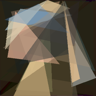
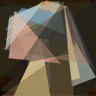
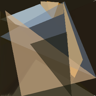
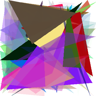

In [8]:
runs = [
    ("RMSE-optimized", "rmse"),
    ("MSE-optimized", "mse"),
    ("DeltaE-optimized", "cielab_delta_e"),
    ("Embedding-cosine-optimized", "embedding_cosine"),
]

thumb_size = (96, 96)
embedding_model = "facebook/dinov2-base"

rows_data = []
for label, run_name in runs:
    image_path = RESULTS_DIR / run_name / "best.png"
    with Image.open(image_path) as im:
        image = np.array(im.convert("RGB").resize((CANVAS_W, CANVAS_H)), dtype=np.uint8)

    rows_data.append({
        "label": label,
        "image": image,
        "metrics": compute_reconstruction_metrics(image, target_array),
    })

cosine_distances = compute_embedding_cosine_distances_batch(
    [row["image"] for row in rows_data],
    target_array,
    model_name=embedding_model,
)

rows_html = []
for row, cosine_distance in zip(rows_data, cosine_distances.tolist(), strict=False):
    cosine_similarity = 1.0 - float(cosine_distance)

    thumb = Image.fromarray(row["image"]).resize(thumb_size)
    buffer = BytesIO()
    thumb.save(buffer, format="PNG")
    encoded = base64.b64encode(buffer.getvalue()).decode("utf-8")
    image_html = f'<img src="data:image/png;base64,{encoded}" width="{thumb_size[0]}" height="{thumb_size[1]}" style="border:1px solid #ccc;border-radius:6px;"/>'

    rows_html.append(
        f"<tr>"
        f"<td style='padding:8px 10px;text-align:left;'>{row['label']}</td>"
        f"<td style='padding:8px 10px;text-align:center;'>{image_html}</td>"
        f"<td style='padding:8px 10px;text-align:right;'>{row['metrics']['rmse']:.3f}</td>"
        f"<td style='padding:8px 10px;text-align:right;'>{row['metrics']['mse']:.3f}</td>"
        f"<td style='padding:8px 10px;text-align:right;'>{row['metrics']['delta_e']:.3f}</td>"
        f"<td style='padding:8px 10px;text-align:right;'>{cosine_similarity:.4f}</td>"
        f"</tr>"
    )

table_html = f"""
<table style='border-collapse:collapse; width:100%; font-family:Arial, sans-serif;'>
  <thead>
    <tr>
      <th style='padding:8px 10px; border-bottom:1px solid #ddd;'>Solution</th>
      <th style='padding:8px 10px; border-bottom:1px solid #ddd;'>Best image (best.png)</th>
      <th style='padding:8px 10px; border-bottom:1px solid #ddd;'>RMSE</th>
      <th style='padding:8px 10px; border-bottom:1px solid #ddd;'>MSE</th>
      <th style='padding:8px 10px; border-bottom:1px solid #ddd;'>DeltaE</th>
      <th style='padding:8px 10px; border-bottom:1px solid #ddd;'>Cosine similarity</th>
    </tr>
  </thead>
  <tbody>
    {''.join(rows_html)}
  </tbody>
</table>
"""

display(HTML(table_html))

## Timelapse GIFs (HTML)

<div style="display:grid;grid-template-columns:repeat(2,minmax(280px,1fr));gap:16px;align-items:start;">
  <div>
    <h4 style="margin:0 0 8px 0;">RMSE</h4>
    <img src="../results/rmse/timelapse.gif" alt="RMSE timelapse" style="width:100%;max-width:420px;border:1px solid #ddd;border-radius:8px;" />
  </div>
  <div>
    <h4 style="margin:0 0 8px 0;">MSE</h4>
    <img src="../results/mse/timelapse.gif" alt="MSE timelapse" style="width:100%;max-width:420px;border:1px solid #ddd;border-radius:8px;" />
  </div>
  <div>
    <h4 style="margin:0 0 8px 0;">Delta E</h4>
    <img src="../results/cielab_delta_e/timelapse.gif" alt="Delta E timelapse" style="width:100%;max-width:420px;border:1px solid #ddd;border-radius:8px;" />
  </div>
  <div>
    <h4 style="margin:0 0 8px 0;">Embedding Cosine</h4>
    <img src="../results/embedding_cosine/timelapse.gif" alt="Embedding Cosine timelapse" style="width:100%;max-width:420px;border:1px solid #ddd;border-radius:8px;" />
  </div>
</div>